In [1]:
!pip install scikit-surprise

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-macosx_11_0_arm64.whl size=447799 sha256=268d3aaf2b32308bdc692d41fcc6dc3c0d8b48a7e5771dbf738cd0951c14f9e6
  Stored in directory: /Users/angeliqueg/Library/Caches/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [2]:
from surprise import Dataset, Reader
import pandas as pd

In [3]:
ratings = pd.read_csv("../data/movie-ratings.txt", header=None)

ratings.columns = [
    "userId",
    "movieId",
    "movieCategoryId",
    "reviewId",
    "movieRating",
    "reviewDate"
]

In [4]:
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    ratings[["userId", "movieId", "movieRating"]],
    reader
)

In [5]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [6]:
from surprise import accuracy

In [9]:
# Model 1
import numpy as np

global_mean = ratings["movieRating"].mean()

predictions_baseline = [
    (uid, iid, r_ui, global_mean)
    for (uid, iid, r_ui) in testset
]

# Fake RMSE/MAE
y_true = [r_ui for (_, _, r_ui, _) in predictions_baseline]
y_pred = [global_mean for _ in predictions_baseline]

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred))
mae_baseline = mean_absolute_error(y_true, y_pred)

In [10]:
# Model 2
from surprise import KNNBasic

sim_options = {
    "name": "cosine",
    "user_based": True
}

user_cf = KNNBasic(sim_options=sim_options)
user_cf.fit(trainset)

predictions_user = user_cf.test(testset)

rmse_user = accuracy.rmse(predictions_user)
mae_user = accuracy.mae(predictions_user)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0839
MAE:  0.8200


In [11]:
# Model 3
sim_options = {
    "name": "cosine",
    "user_based": False
}

item_cf = KNNBasic(sim_options=sim_options)
item_cf.fit(trainset)

predictions_item = item_cf.test(testset)

rmse_item = accuracy.rmse(predictions_item)
mae_item = accuracy.mae(predictions_item)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1023
MAE:  0.8296


In [12]:
# Model 4
from surprise import SVD

svd = SVD()
svd.fit(trainset)

predictions_svd = svd.test(testset)

rmse_svd = accuracy.rmse(predictions_svd)
mae_svd = accuracy.mae(predictions_svd)

RMSE: 0.9548
MAE:  0.7384


In [ ]:
# Comparison
results = pd.DataFrame({
    "Model": [
        "Global Average",
        "User-Based CF",
        "Item-Based CF",
        "SVD"
    ],
    "RMSE": [
        rmse_baseline,
        accuracy.rmse(predictions_user, verbose=False),
        accuracy.rmse(predictions_item, verbose=False),
        accuracy.rmse(predictions_svd, verbose=False)
    ],
    "MAE": [
        mae_baseline,
        accuracy.mae(predictions_user, verbose=False),
        accuracy.mae(predictions_item, verbose=False),
        accuracy.mae(predictions_svd, verbose=False)
    ]
})

results

,Model,RMSE,MAE
0,Global Average,1.088628,0.839936
1,User-Based CF,1.083883,0.819977
2,Item-Based CF,1.102340,0.829645
3,SVD,0.954816,0.738422


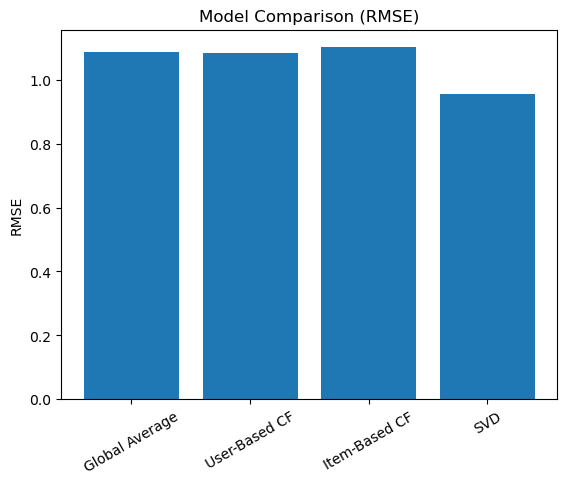

In [14]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

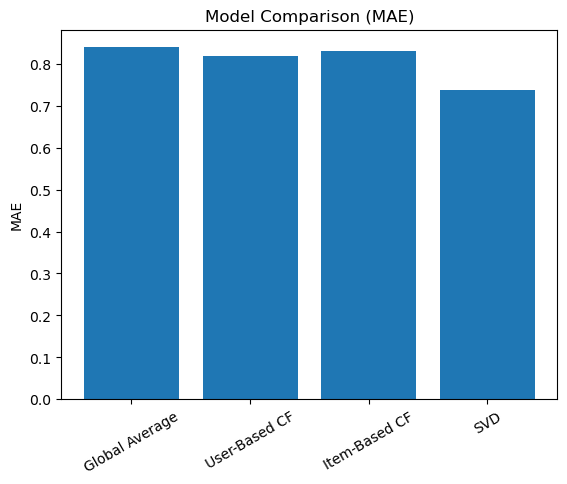

In [15]:
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.show()